In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math

In [36]:
### Helper Functions ###

def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def plot_images(images, titles=None, cols=3, figsize=(15, 10)):
    # Number of images
    num_images = len(images)
    
    # Calculate number of rows
    rows = math.ceil(num_images / cols)
    
    # Create the subplot grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.ravel()  # Flatten the 2D grid of axes to iterate over
    
    # Loop through each image and corresponding axis
    for i in range(rows * cols):
        if i < num_images:
            # Display image
            axes[i].imshow(images[i], cmap='gray' if len(images[i].shape) == 2 else None)
            
            # Add title if provided
            if titles:
                axes[i].set_title(titles[i], fontsize=12)
        else:
            # Hide any unused subplot
            axes[i].axis('off')
        
        # Remove axes for clarity
        axes[i].axis('off')
    
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

# Task 1

# Task 2

In [37]:
data_dir = "./Task-2"
image_path = os.path.join(data_dir, "AF1.jpg")
image = cv2.imread(image_path)

In [38]:
def remove_blinds(image):
    kernel_size = 37

    # Create Gabor kernel for horizontal line detection.
    gabor_kernel = cv2.getGaborKernel(
        ksize=(kernel_size, kernel_size),
        sigma=3.0,
        theta=0,
        lambd=17.5,
        gamma=0.5,
        psi=0,
        ktype=cv2.CV_32F
    )

    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Compute the Fourier Transform of the grayscale image.
    dft_image = np.fft.fft2(gray_image)
    # Shift the zero frequency to the center.
    dft_image_shifted = np.fft.fftshift(dft_image)
    # Compute the magnitude spectrum (log scale to enhance visualization).
    magnitude = np.abs(dft_image_shifted)  # Get the magnitude of the Fourier coefficients
    magnitude_log = np.log(magnitude + 1)  # Apply log for better visualization

    # Process each channel separately
    filtered_channels = []

    for channel in cv2.split(image):
        ### Compute the Fourier Transform of the colour channel ###
        dft_channel = np.fft.fft2(channel)
        # Shift the zero frequency to the center.
        dft_channel_shifted = np.fft.fftshift(dft_channel)

        ### Compute the Fourier Transform of the Gabor filter. ###
        # Padding the Gabor kernel to match the size of the channel.
        padded_gabor_kernel = np.zeros_like(channel, dtype=np.float64)
        k_center = kernel_size // 2
        padded_gabor_kernel[:kernel_size, :kernel_size] = gabor_kernel
        # Center the kernel by rolling it to the middle of the padded array.
        padded_gabor_kernel = np.roll(padded_gabor_kernel, -k_center, axis=0)
        padded_gabor_kernel = np.roll(padded_gabor_kernel, -k_center, axis=1)
        # Compute the Fourier Transform of the padded Gabor kernel to convert iage into the frequency domain.
        dft_gabor_kernel = np.fft.fft2(padded_gabor_kernel)
        # Shift the zero-frequency component (DC component) of the Gabor kernel's Fourier Transform
        # to the center of the spectrum for alignment with the image's Fourier Transform.
        dft_gabor_kernel_shifted = np.fft.fftshift(dft_gabor_kernel)

        ### Perform element-wise multiplication in the frequency domain. ###
        # This applies the Gabor filter in the frequency domain.
        filtered_dft = dft_channel_shifted * dft_gabor_kernel_shifted

        # Inverse Fourier Transform to get the filtered image back in spatial domain.
        filtered_dft_shifted_back = np.fft.ifftshift(filtered_dft)
        filtered_image = np.fft.ifft2(filtered_dft_shifted_back)
        filtered_image_real = np.real(filtered_image)

        # Normalize the filtered colour channel to the range [0, 255].
        filtered_channel_normalized = cv2.normalize(filtered_image_real, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # Apply denoising to the normalized channel to reduce noise artifacts.
        filtered_channel_normalized = cv2.fastNlMeansDenoising(filtered_channel_normalized)

        filtered_channels.append(filtered_channel_normalized)

    # Merge the processed channels back together
    return magnitude_log, bgr_to_rgb(cv2.merge(filtered_channels))

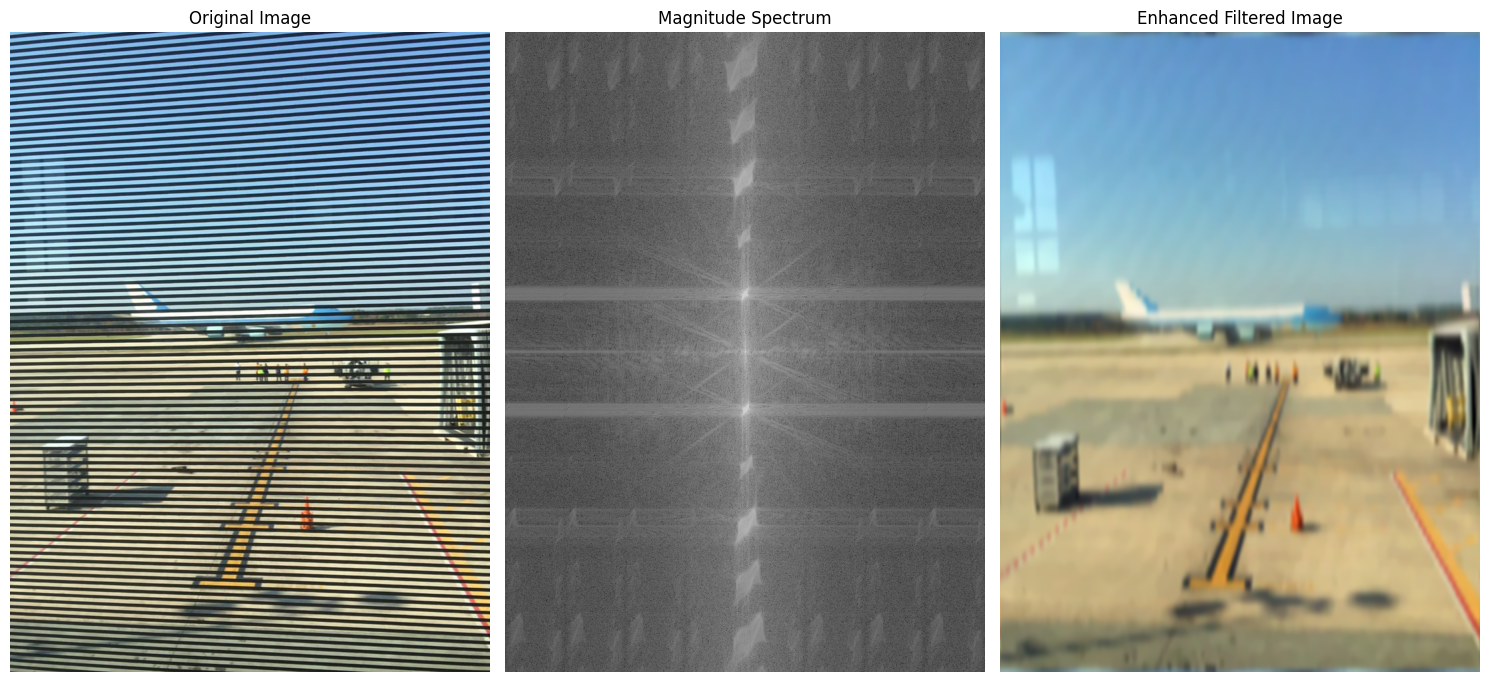

In [39]:
magnitude_spectrum, result = remove_blinds(image)

plot_images(
    images=[bgr_to_rgb(image), magnitude_spectrum, result],
    titles=["Original Image", "Magnitude Spectrum", "Enhanced Filtered Image"],
)

# Task 3

In [40]:
data_dir = "./Task-3"

source_paths = [os.path.join(data_dir, image) for image in ["zebra_crossing1.png", "zebra_crossing2.png"]]
sources = [cv2.imread(path) for path in source_paths]

target_path = os.path.join(data_dir, "zebra_crossing_reference.jpg")
target = cv2.imread(target_path)

In [41]:
def extract_roi(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Threshold the image to create a binary image (non-black areas will be white)
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    
    # Find contours of the non-black areas
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Find the bounding box of the largest contour (which should be the region of interest)
    x, y, w, h = cv2.boundingRect(contours[0])
    
    return x, y, w, h


# Crop the image to the bounding box (ROI)
def crop_image(image, x, y, w, h):
    return image[y:y+h, x:x+w]

In [42]:
def manually_align_images(source_color, source_gray, target_color, target_gray):
    """
    Manually aligns source and target images by allowing the user to select corresponding points.
    
    Args:
        source_color (ndarray): Source image in color.
        source_gray (ndarray): Source image in grayscale.
        target_color (ndarray): Target image in color.
        target_gray (ndarray): Target image in grayscale.
    
    Returns:
        aligned_source (ndarray): The aligned source image.
        matched_img (ndarray): Visualization of matched points.
    """

    def select_points(image, window_name):
        """
        Allows the user to manually select points on an image by clicking.
        Press Enter to finish the selection.
        
        Args:
            image (ndarray): Image to display for point selection.
            window_name (str): Name of the OpenCV window.

        Returns:
            points (list): List of selected points.
        """
        points = []
        drawing = [image.copy()]  # Use a list to store the updated image (mutable)

        def draw_and_select(event, x, y, flags, param):
            if event == cv2.EVENT_LBUTTONDOWN:
                points.append((x, y))
                # Draw the clicked point and lines connecting points
                for i, pt in enumerate(points):
                    cv2.circle(drawing[0], pt, 5, (0, 255, 0), -1)  # Draw point

                cv2.imshow(window_name, drawing[0])  # Update the image display

        # Display the image for point selection
        cv2.imshow(window_name, image)
        cv2.setMouseCallback(window_name, draw_and_select)

        # Wait for the user to finish point selection by pressing Enter
        while True:
            key = cv2.waitKey(1) & 0xFF
            if key == 13:  # Enter key
                break

        cv2.destroyWindow(window_name)
        return points

    # Select points for the source image
    source_points = select_points(source_color, "Select Points - Source Image")
    print(f"Selected points from source: {source_points}")

    # Select points for the target image
    target_points = select_points(target_color, "Select Points - Target Image")
    print(f"Selected points from target: {target_points}")

    # Convert points to NumPy arrays
    src_pts = np.float32(source_points).reshape(-1, 1, 2)
    tgt_pts = np.float32(target_points).reshape(-1, 1, 2)

    # Compute the homography matrix
    H, mask = cv2.findHomography(src_pts, tgt_pts, cv2.RANSAC, 5.0)

    # Warp the source image
    height, width = target_gray.shape
    aligned_source = cv2.warpPerspective(source_color, H, (width, height))

    # Create a combined image for SIFT-style visualization
    combined_width = source_color.shape[1] + target_color.shape[1]
    combined_height = max(source_color.shape[0], target_color.shape[0])
    combined_img = np.zeros((combined_height, combined_width, 3), dtype=np.uint8)

    # Place source and target images side by side
    combined_img[:source_color.shape[0], :source_color.shape[1]] = source_color
    combined_img[:target_color.shape[0], source_color.shape[1]:] = target_color

    # Draw the points and connecting lines
    for (sx, sy), (tx, ty) in zip(source_points, target_points):
        # Draw source points (green dots)
        cv2.circle(combined_img, (int(sx), int(sy)), 5, (0, 255, 0), -1)

        # Draw target points (red dots)
        cv2.circle(combined_img, (int(tx) + source_color.shape[1], int(ty)), 5, (0, 0, 255), -1)

        # Draw connecting lines (blue)
        cv2.line(combined_img, (int(sx), int(sy)), (int(tx) + source_color.shape[1], int(ty)), (255, 0, 0), 2)

    return aligned_source, combined_img

In [43]:
def automatically_align_images(source_color, source_gray, target_color, target_gray):
    target_height, target_width = target_gray.shape

    # Extract ROI from target image (remove the black box if needed)
    x, y, w, h = extract_roi(source_color)

    # Crop the images based on ROI
    source_color = crop_image(source_color, x, y, w, h)
    source_gray = crop_image(source_gray, x, y, w, h)

    # Resize back up to target image size
    source_color = cv2.resize(source_color, (target_width, target_height))
    source_gray = cv2.resize(source_gray, (target_width, target_height))

    orb = cv2.ORB_create()

    # Detect keypoints and descriptors
    source_kp, source_des = orb.detectAndCompute(source_gray, None)
    target_kp, target_des = orb.detectAndCompute(target_gray, None)

    # Match descriptors using BFMatcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(source_des, target_des)
    
    # Sort matches by distance (best matches first)
    matches = sorted(matches, key=lambda x: x.distance)

    # Extract the corresponding points
    source_pts = np.float32([source_kp[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    target_pts = np.float32([target_kp[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    # Compute the homography
    H, mask = cv2.findHomography(source_pts, target_pts, cv2.RANSAC, 5.0)

    # Warp the source image to align with the target
    aligned_source = cv2.warpPerspective(source_color, H, (target_width, target_height))

    # Draw the matches
    matched_img = cv2.drawMatches(source_color, source_kp, target_color, target_kp, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    return aligned_source, matched_img

In [44]:
def align_images(source, target, selection="automatic"):
    source_gray = cv2.cvtColor(source, cv2.COLOR_BGR2GRAY)
    target_gray = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)

    # Feature detection and matching
    if selection == "automatic":
        aligned_source, matched_img = automatically_align_images(
            source, source_gray, target, target_gray
        )
    elif selection == "manual":
        aligned_source, matched_img = manually_align_images(
            source, source_gray, target, target_gray
        )

    plot_images(
        images=[
            bgr_to_rgb(source),
            bgr_to_rgb(target),
            bgr_to_rgb(matched_img),
            bgr_to_rgb(aligned_source),
        ],
        titles=["source", "target", "Matched Points", "Transformed/aligned source"],
    )

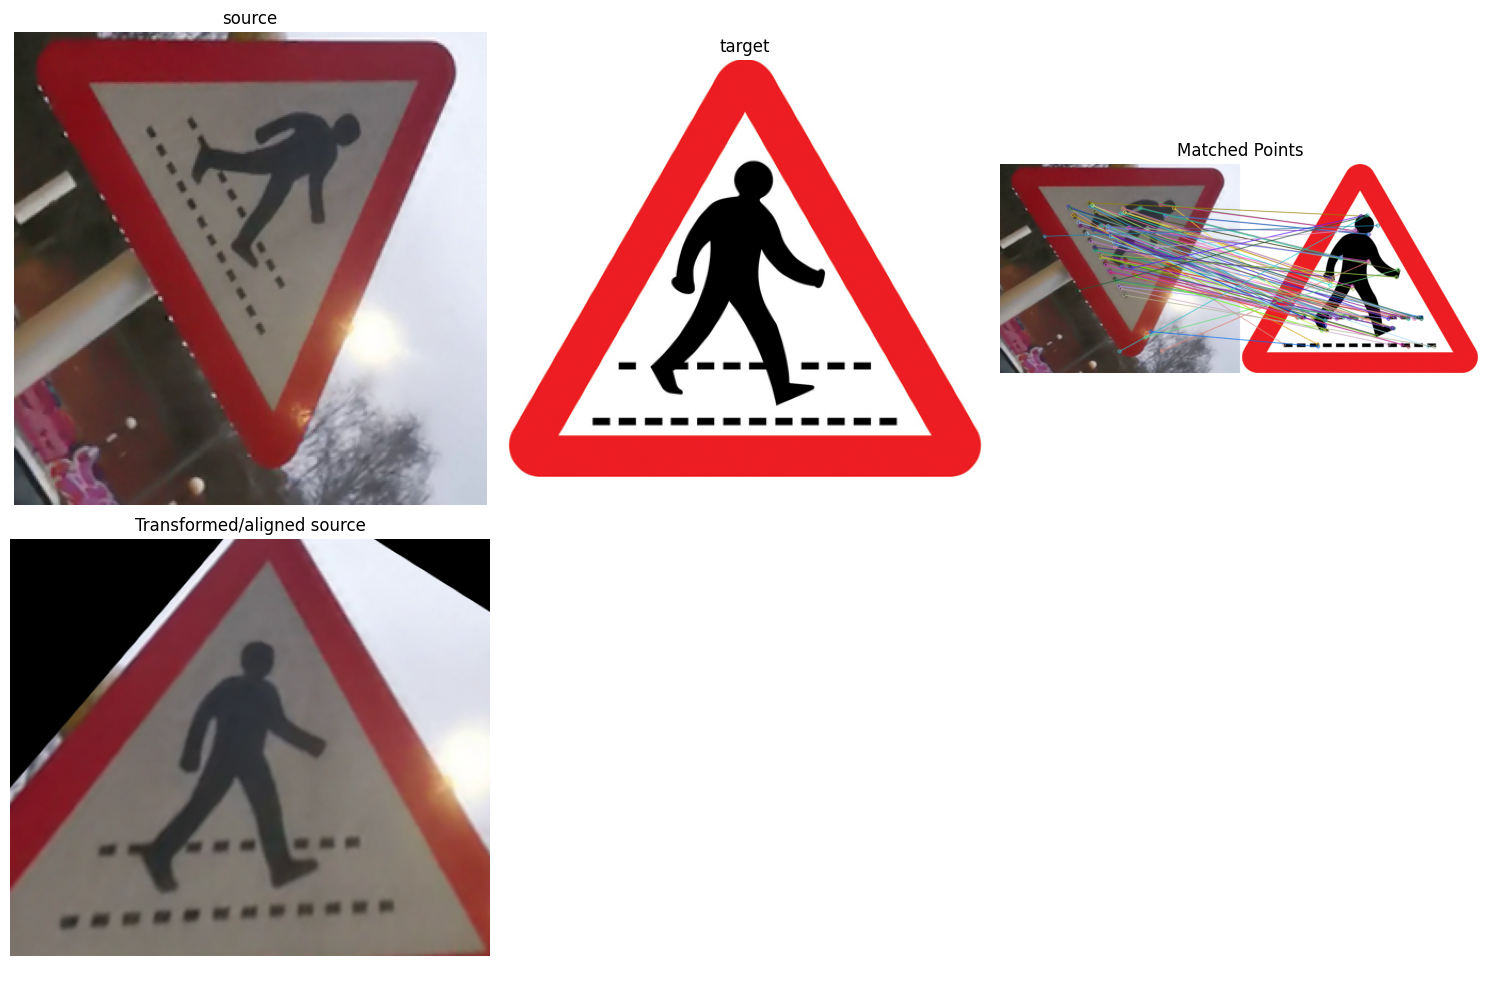

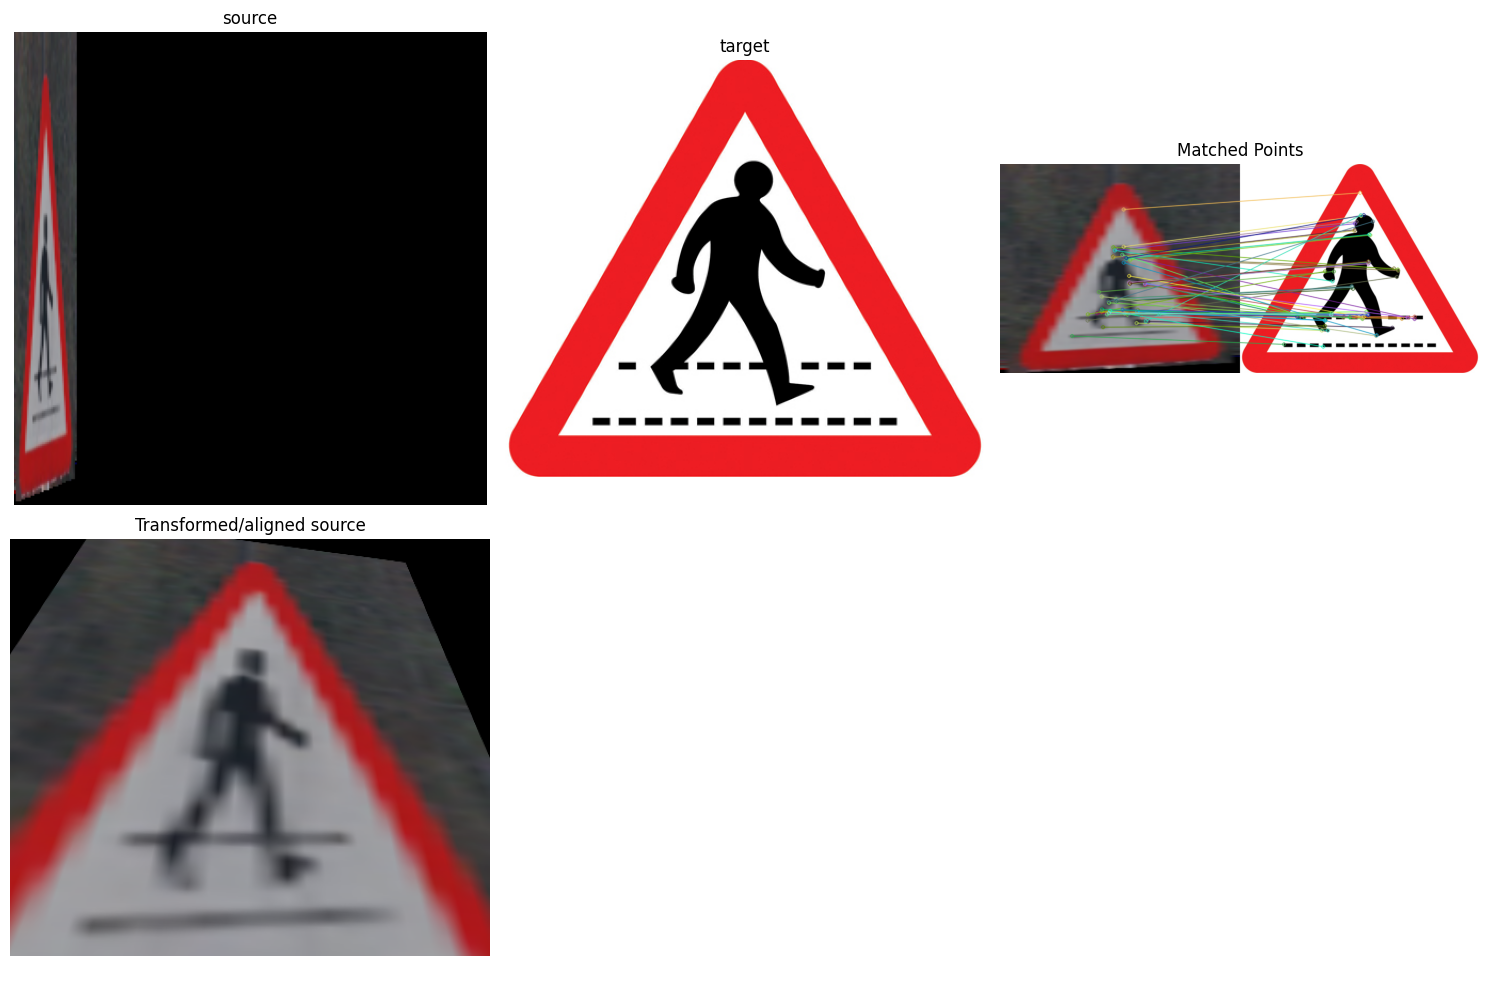

In [ ]:
for source in sources:
    align_images(source, target, 'automatic')

# Uncomment for manual
# align_images(source[0], target, 'manual')
# align_images(source[1], target, 'manual')

# Task 4
